# Orange County Residential: Distressed Seller Signal Detection

**Goal:** Identify Orange County zip codes showing signs of seller motivation / financial pressure —
potential off-market and below-market acquisition opportunities for Candice's buy-and-hold clients.

**Data sources:**
- Zillow price cuts by zip (seller desperation)
- Zillow inventory change (supply build-up)
- Census ACS vacancy rates
- Census Building Permits Survey — Orange County, monthly (capital deployment signal)

### A note on data availability vs. the SF Bay Area version of this analysis

The original SF model used **eviction notices** (SF OpenData) and **zip-level building permits** (SF's own
Socrata portal) as core distress signals. Neither has a real equivalent here:

- **California eviction filings are largely sealed court records**, not open data. Eviction Lab and other
  trackers do not have reliable Orange County coverage. There is no honest substitute — this signal is
  simply **dropped** rather than approximated.
- Orange County has **30+ incorporated cities**, each with its own permit system, and no unified zip-level
  open-data feed (the County's own open-data portal only covers unincorporated land, a small sliver of OC).
  The federal **Census Building Permits Survey** fills this gap, but only at the **county level** — it
  cannot be broken out by zip code.

**What this means practically:** the zip-level distress score below is built from price cuts, vacancy, and
inventory growth only. The permit trend is shown separately as a county-wide capital-deployment indicator,
not blended into the zip score. This is a real limitation — flag it to clients rather than overstate
precision. If Candice later gets MLS or a paid data feed (PropStream, Reonomy, etc.), that would restore
eviction/foreclosure-equivalent signal at the property level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data/raw')
OUT  = Path('../outputs')
(OUT / 'charts').mkdir(exist_ok=True)
(OUT / 'tables').mkdir(exist_ok=True)

## 1. County-wide permit activity — capital deployment signal

In [2]:
permits = pd.read_csv(DATA / 'oc_building_permits_monthly.csv', dtype={'state_fips': str, 'county_fips': str})
permits['survey_date'] = permits['survey_date'].astype(str)
permits['date'] = pd.to_datetime(permits['survey_date'], format='%Y%m')
permits = permits.sort_values('date')

print(f'Permit data: {len(permits)} months, {permits["date"].min().date()} to {permits["date"].max().date()}')
permits[['date','units_total','units_multifamily','bldgs_5plusunit']].tail()

Permit data: 70 months, 2020-07-01 to 2026-05-01


,date,units_total,units_multifamily,bldgs_5plusunit
65,2026-01-01,641,430,5
66,2026-02-01,776,545,4
67,2026-03-01,747,391,6
68,2026-04-01,591,299,10
69,2026-05-01,269,31,3


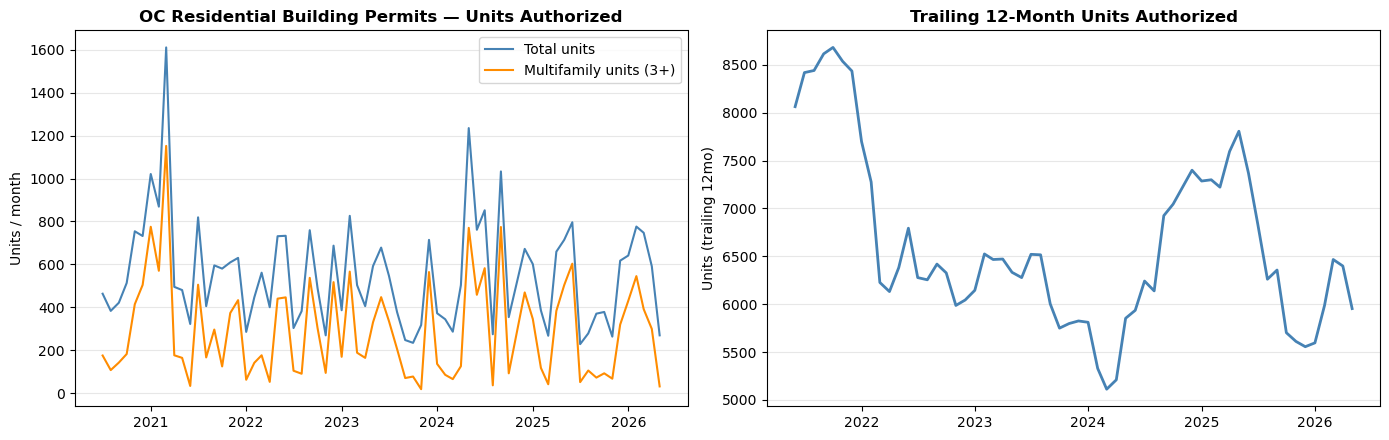

Trailing 12mo units authorized: 5,954  (YoY: -23.7%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(permits['date'], permits['units_total'], color='steelblue', linewidth=1.5, label='Total units')
axes[0].plot(permits['date'], permits['units_multifamily'], color='darkorange', linewidth=1.5, label='Multifamily units (3+)')
axes[0].set_title('OC Residential Building Permits — Units Authorized', fontweight='bold')
axes[0].set_ylabel('Units / month')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Trailing 12mo sum, YoY comparison
permits_idx = permits.set_index('date')
trailing12 = permits_idx['units_total'].rolling(12).sum()
axes[1].plot(trailing12.index, trailing12.values, color='steelblue', linewidth=2)
axes[1].set_title('Trailing 12-Month Units Authorized', fontweight='bold')
axes[1].set_ylabel('Units (trailing 12mo)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'charts/permits_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

latest12 = trailing12.iloc[-1]
prior12 = trailing12.iloc[-13] if len(trailing12) > 13 else np.nan
yoy = (latest12 / prior12 - 1) * 100 if pd.notna(prior12) else np.nan
print(f'Trailing 12mo units authorized: {latest12:,.0f}  (YoY: {yoy:+.1f}%)' if pd.notna(yoy) else f'Trailing 12mo units authorized: {latest12:,.0f}')

## 2. Zip-level distress score (price cuts, vacancy, inventory)

In [4]:
mkt = pd.read_csv(OUT / 'tables/market_selection_ranked.csv', dtype={'zip_code': str})

def pct_rank(s, invert=False):
    filled = s.fillna(s.median())
    r = filled.rank(pct=True) * 100
    return (100 - r) if invert else r

distress = mkt[['zip_code','City','investment_score','vacancy_rate','price_cut_rate','inv_chg_6m_pct']].copy()

distress['d_vacancy']    = pct_rank(distress['vacancy_rate'])
distress['d_price_cuts'] = pct_rank(distress['price_cut_rate'])
distress['d_inventory']  = pct_rank(distress['inv_chg_6m_pct'])

# Weighted toward price cuts (most direct seller-motivation signal in available data)
distress['distress_score'] = (
    distress['d_price_cuts'] * 0.45 +
    distress['d_inventory']  * 0.30 +
    distress['d_vacancy']    * 0.25
)

distress = distress.sort_values('distress_score', ascending=False)

print('Top 15 zip codes by distress score (highest = most seller-motivation signal):')
cols_show = ['zip_code','City','distress_score','price_cut_rate','inv_chg_6m_pct','vacancy_rate','investment_score']
distress[cols_show].head(15).round(2)

Top 15 zip codes by distress score (highest = most seller-motivation signal):


,zip_code,City,distress_score,price_cut_rate,inv_chg_6m_pct,vacancy_rate,investment_score
69,92602,Irvine,90.99,0.33,56.06,0.08,41.40
48,92603,Irvine,80.70,0.23,71.05,0.11,47.50
82,92637,Laguna Woods,79.77,0.31,22.61,0.14,30.52
3,92627,Costa Mesa,79.30,0.29,56.45,0.04,65.64
75,92612,Irvine,78.95,0.31,19.23,0.11,37.97
55,92801,Anaheim,78.20,0.24,103.03,0.05,45.93
54,92662,Newport Beach,77.47,NaN,216.67,0.63,46.16
83,92692,Mission Viejo,77.38,0.31,31.09,0.05,29.71
30,92649,Huntington Beach,76.98,0.30,50.62,0.04,54.71
49,92705,North Tustin,76.05,0.27,31.94,0.05,47.27


## 3. Opportunity Matrix

Distress score (seller motivation) vs. market attractiveness score (fundamentals) — the target zone is
high distress **and** high market quality: motivated sellers in submarkets worth owning long-term.

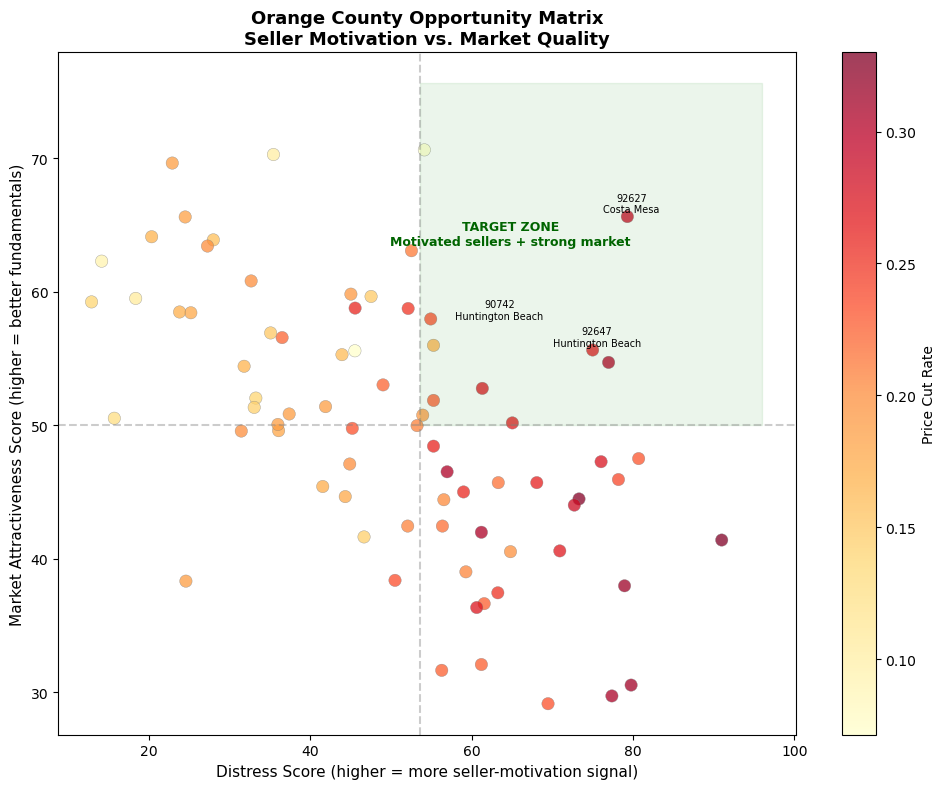


Top target zips (high distress + high market quality):
zip_code             City  distress_score  investment_score
   92627       Costa Mesa       79.302326         65.639535
   92647 Huntington Beach       75.000000         55.639535
   90742 Huntington Beach       62.936047         57.674419


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    distress['distress_score'],
    distress['investment_score'],
    c=distress['price_cut_rate'],
    cmap='YlOrRd',
    s=80,
    alpha=0.75,
    edgecolors='gray',
    linewidth=0.3
)
plt.colorbar(scatter, label='Price Cut Rate')

ax.axvline(distress['distress_score'].median(), color='gray', linestyle='--', alpha=0.4)
ax.axhline(distress['investment_score'].median(), color='gray', linestyle='--', alpha=0.4)

target = distress[
    (distress['distress_score'] > distress['distress_score'].quantile(0.65)) &
    (distress['investment_score'] > distress['investment_score'].quantile(0.65))
]
for _, row in target.iterrows():
    ax.annotate(
        f"{row['zip_code']}\n{row['City']}",
        (row['distress_score'], row['investment_score']),
        fontsize=7, ha='center',
        xytext=(3, 3), textcoords='offset points'
    )

ax.fill_betweenx(
    [distress['investment_score'].median(), distress['investment_score'].max() + 5],
    distress['distress_score'].median(),
    distress['distress_score'].max() + 5,
    alpha=0.08, color='green'
)
ax.text(
    distress['distress_score'].quantile(0.80),
    distress['investment_score'].quantile(0.92),
    'TARGET ZONE\nMotivated sellers + strong market',
    fontsize=9, color='darkgreen', fontweight='bold', ha='center'
)

ax.set_xlabel('Distress Score (higher = more seller-motivation signal)', fontsize=11)
ax.set_ylabel('Market Attractiveness Score (higher = better fundamentals)', fontsize=11)
ax.set_title('Orange County Opportunity Matrix\nSeller Motivation vs. Market Quality', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(OUT / 'charts/opportunity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop target zips (high distress + high market quality):')
target_sorted = target.sort_values('distress_score', ascending=False)
print(target_sorted[['zip_code','City','distress_score','investment_score']].head(10).to_string(index=False))

## 4. Export

In [6]:
distress.to_csv(OUT / 'tables/distress_scores_ranked.csv', index=False)
print(f'Saved distress scores to outputs/tables/distress_scores_ranked.csv')

permits.to_csv(OUT / 'tables/permit_activity_monthly.csv', index=False)
print(f'Saved permit activity to outputs/tables/permit_activity_monthly.csv')

Saved distress scores to outputs/tables/distress_scores_ranked.csv
Saved permit activity to outputs/tables/permit_activity_monthly.csv
